# 07 — Calibration robustness check

**Purpose:** Test whether spatial multiplicity (variance, Moran's I, LISA hotspots) is driven by probability miscalibration across model families.

- Uses **only saved artifacts** (no retraining, same Rashomon selection).
- **Platt scaling** (LogisticRegression on predicted probabilities) fitted on **validation set only**; applied to test predictions.
- Recompute multiplicity and spatial metrics on calibrated predictions and compare to uncalibrated.

## 1. Calibration procedure

For each run:
1. Select Rashomon models (top-K by validation Brier from meta.csv).
2. For each selected model: fit **Platt scaling** (sklearn LogisticRegression on predicted probabilities) using **validation** (P_val, y_val) only.
3. Apply the fitted mapping to **test** probabilities (P_test). Test labels are never used.
4. Produce calibrated test matrix P_test_calibrated (n_models, n_test).

Then recompute on calibrated P: mean variance, ambiguity, disagreement rate (ε=0.05), discrepancy, pointwise variance, Moran's I (k=30), LISA HH masks, HH count, component sizes, and Jaccard(HH_before, HH_after).

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from analysis.experiment_runner import _get_run_dirs
from analysis.calibration import run_calibration_experiment

RESULTS_DIR = ROOT / "results"
K = 25
dataset_dirs = [p for p in RESULTS_DIR.iterdir() if p.is_dir() and _get_run_dirs(p)]

per_run_list = []
summary_list = []
for dataset_dir in dataset_dirs:
    dataset_name = dataset_dir.name
    
    if "synthetic" in dataset_name:
        continue

    per_run_d, summary_d = run_calibration_experiment(
        dataset_dir,
        dataset_name=dataset_name,
        K=K,
        k_nn=30,
        epsilon=0.05,
    )
    per_run_d = per_run_d.assign(dataset=dataset_name)
    summary_d = summary_d.assign(dataset=dataset_name)
    per_run_list.append(per_run_d)
    summary_list.append(summary_d)

per_run_df = pd.concat(per_run_list, ignore_index=True)
summary_df = pd.concat(summary_list, ignore_index=True)
print(f"Total runs: {len(per_run_df)} (datasets: {', '.join(per_run_df['dataset'].unique())})")
print("Per-dataset CSVs saved under each dataset dir: calibration_summary_per_run.csv, calibration_summary.csv")

c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weights matrix is not fully connected: 
 There are 2 disconnected components.
  W.__init__(self, neighbors, id_order=ids, **kwargs)
c:\Users\dejvi\Documents\pythonProject\Rashomon Sets\rashomon-multiplicity\.venv\Lib\site-packages\libpysal\weights\distance.py:153: UserWarning: The weig

Total runs: 40 (datasets: adult, breast_cancer, compas, german)
Per-dataset CSVs saved under each dataset dir: calibration_summary_per_run.csv, calibration_summary.csv


## 2. Metric comparison table

Before vs after calibration (per run) and aggregated Δ (mean ± std).

In [2]:
display(per_run_df)
print("\nAggregated (mean ± std over runs):")
display(summary_df)

,run,brier_before,brier_after,brier_improvement,mean_variance_before,mean_variance_after,delta_mean_variance,mean_conflict_before,mean_conflict_after,delta_mean_conflict,...,disagreement_rate_before,disagreement_rate_after,discrepancy_before,discrepancy_after,jaccard_HH_before_after,n_components_before,n_components_after,max_component_size_before,max_component_size_after,dataset
0,seed=0,0.088879,0.091190,-2.311148e-03,0.001461,0.001754,0.000293,0.016501,0.016100,-0.000401,...,0.138746,0.120992,0.045692,0.038608,0.459459,4,3,18,49,adult
1,seed=1,0.087408,0.089357,-1.948318e-03,0.001306,0.001560,0.000253,0.016747,0.015797,-0.000950,...,0.142327,0.122541,0.054616,0.043683,0.555270,4,2,154,259,adult
2,seed=2,0.087919,0.090867,-2.947316e-03,0.001474,0.001764,0.000290,0.018008,0.017173,-0.000835,...,0.151163,0.124220,0.061630,0.048988,0.396285,5,5,90,147,adult
3,seed=3,0.089963,0.092539,-2.576544e-03,0.001587,0.001890,0.000303,0.019060,0.018045,-0.001015,...,0.159343,0.131639,0.056750,0.047307,0.398671,4,5,92,129,adult
4,seed=4,0.088864,0.091480,-2.615772e-03,0.001433,0.001689,0.000256,0.018135,0.017336,-0.000798,...,0.150443,0.126074,0.053568,0.044013,0.351682,5,4,97,144,adult
5,seed=5,0.088905,0.091912,-3.006964e-03,0.001454,0.001779,0.000325,0.017500,0.017140,-0.000360,...,0.144945,0.125641,0.045694,0.040231,0.448669,6,3,81,157,adult
6,seed=6,0.088166,0.090833,-2.666415e-03,0.001150,0.001516,0.000366,0.016358,0.015367,-0.000991,...,0.127509,0.114724,0.048115,0.039384,0.350711,4,6,60,73,adult
7,seed=7,0.087939,0.090353,-2.413537e-03,0.001444,0.001855,0.000411,0.017983,0.017578,-0.000405,...,0.150763,0.131060,0.062544,0.052156,0.479218,4,4,190,289,adult
8,seed=8,0.088252,0.091098,-2.845523e-03,0.001278,0.001613,0.000335,0.016038,0.015744,-0.000295,...,0.122429,0.112236,0.043926,0.037486,0.455357,2,3,32,45,adult
9,seed=9,0.089453,0.092059,-2.606066e-03,0.001244,0.001542,0.000298,0.015776,0.015568,-0.000209,...,0.135728,0.118331,0.053630,0.044493,0.372294,3,6,59,85,adult



Aggregated (mean ± std over runs):


,metric,mean,std,mean_plus_minus_std,dataset
0,delta_mean_variance,0.000313,0.000049,0.0003 ± 0.0000,adult
1,delta_moran_i,0.001906,0.006744,0.0019 ± 0.0067,adult
2,delta_n_HH,15.000000,27.988093,15.0000 ± 27.9881,adult
3,jaccard_HH_before_after,0.426762,0.064754,0.4268 ± 0.0648,adult
4,brier_improvement,-0.002594,0.000315,-0.0026 ± 0.0003,adult
5,delta_mean_variance,0.002112,0.001775,0.0021 ± 0.0018,breast_cancer
6,delta_moran_i,-0.012794,0.022489,-0.0128 ± 0.0225,breast_cancer
7,delta_n_HH,-1.200000,2.820559,-1.2000 ± 2.8206,breast_cancer
8,jaccard_HH_before_after,0.808333,0.355838,0.8083 ± 0.3558,breast_cancer
9,brier_improvement,-0.000342,0.002015,-0.0003 ± 0.0020,breast_cancer


## 3. Spatial comparison plots

Compare Moran's I and HH count before vs after calibration across runs.

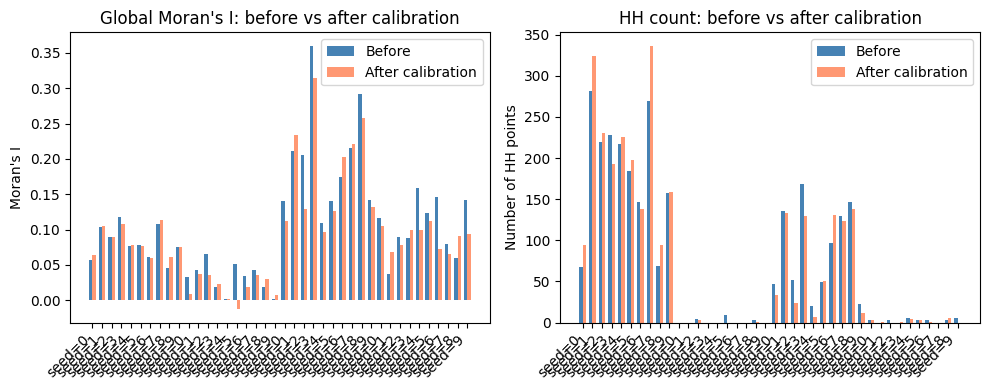

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
runs = per_run_df["run"].values
x = np.arange(len(runs))
w = 0.35
axes[0].bar(x - w/2, per_run_df["moran_i_before"], width=w, label="Before", color="steelblue")
axes[0].bar(x + w/2, per_run_df["moran_i_after"], width=w, label="After calibration", color="coral", alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(runs, rotation=45, ha="right")
axes[0].set_ylabel("Moran's I")
axes[0].set_title("Global Moran's I: before vs after calibration")
axes[0].legend()

axes[1].bar(x - w/2, per_run_df["n_HH_before"], width=w, label="Before", color="steelblue")
axes[1].bar(x + w/2, per_run_df["n_HH_after"], width=w, label="After calibration", color="coral", alpha=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(runs, rotation=45, ha="right")
axes[1].set_ylabel("Number of HH points")
axes[1].set_title("HH count: before vs after calibration")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Jaccard overlap analysis

Jaccard(HH_before, HH_after) measures how much the set of HH hotspots changes after calibration. High overlap → similar hotspots; low overlap → calibration shifts where hotspots appear.

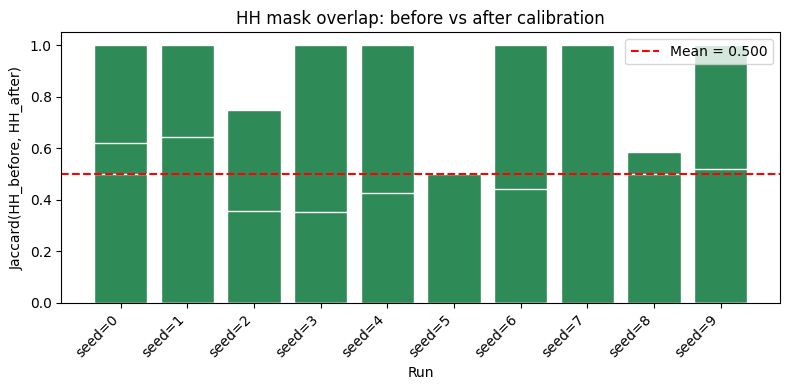

Mean Jaccard overlap (HH before vs after): 0.4995 ± 0.3134


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(per_run_df["run"], per_run_df["jaccard_HH_before_after"], color="seagreen", edgecolor="white")
ax.axhline(per_run_df["jaccard_HH_before_after"].mean(), color="red", linestyle="--", label=f"Mean = {per_run_df['jaccard_HH_before_after'].mean():.3f}")
ax.set_ylabel("Jaccard(HH_before, HH_after)")
ax.set_xlabel("Run")
ax.set_title("HH mask overlap: before vs after calibration")
ax.legend()
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(f"Mean Jaccard overlap (HH before vs after): {per_run_df['jaccard_HH_before_after'].mean():.4f} ± {per_run_df['jaccard_HH_before_after'].std():.4f}")

## 5. Interpretation

- **If spatial metrics remain similar after calibration** (small Δ Moran's I, Δ HH count; high Jaccard overlap): multiplicity is **structural** — disagreement and clustering are not mainly due to probability miscalibration.

- **If spatial clustering weakens substantially** after calibration (Moran's I drops, HH count drops, low Jaccard): the effect is **partly due to miscalibration** — calibrating probabilities reduces both overall spread and the spatial concentration of disagreement.

Use the aggregated summary (Δ mean_variance, Δ Moran's I, Δ HH count, mean Jaccard) to draw conclusions for the dataset.